# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
# Not needed for this local project: dependencies are installed from requirements.txt
# into the local .venv (Python 3.14). This starter cell targeted the Udacity cloud
# workspace and an old kaggle version, so it is commented out.
# !python -m pip install kaggle==1.6.12

In [2]:
# Not needed for this local project. The original `--target=/workspace` path is the
# Udacity cloud workspace (nonexistent locally), and numpy==1.24.3 will not build on
# Python 3.14. ucimlrepo/numpy are already installed in the local .venv, so this is
# commented out.
# !pip install --target=/workspace ucimlrepo numpy==1.24.3

**Note:** Not applicable here — the two install cells above are commented out because dependencies are installed from `requirements.txt` into the local `.venv` (Python 3.14). No kernel restart is needed. *(Originally: "Restart the kernel to use updated package(s).")*

### Import libraries

All libraries used throughout the notebook are imported here, at the top. The standard-library modules (`os`, `io`, `time`, `xml.etree.ElementTree`) need no installation; `pandas` and `requests` are installed from `requirements.txt`.

In [9]:
# Import the libraries used throughout this notebook.
# Standard library (no installation needed):
import os
import io
import time
import xml.etree.ElementTree as ET

# Third-party (installed from requirements.txt):
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Render matplotlib/seaborn figures inline in the notebook.
%matplotlib inline

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

### **1.1.** Problem Statement
In 2-4 sentences, explain the kind of problem you want to look at and the datasets you will be wrangling for this project.

In the Udacity Master's Degree in AI, I would like to investigate the possibility of using AI to predict the infrared spectral lines of complex aromatic molecules, so that they can be used to identify them in observations from space telescopes. To prepare for this work, I would like to familiarize myself with some of the world's molecular datasets, in this project's case: the NASA Ames PAH IR Spectroscopic Database on the one hand, and PubChem on the other. I would like to try to connect them if that is at all possible. For the sake of this Data Wrangling project, the research question could be:  

*How does the number of distinct infrared emission lines vary with an aromatic molecule's size (molecular weight or carbon count), and do neutral and ionized aromatics differ in this respect?*

For this project, the two datasets are sourced from the following:

* **NASA Ames PAH IR Spectroscopic Database (PAHdb)** — infrared spectra of polycyclic aromatic hydrocarbons (theoretical library): https://www.astrochemistry.org/pahdb/
* **PubChem** — chemical structure and molecular properties, from the NCBI/NIH database: https://pubchem.ncbi.nlm.nih.gov/ (programmatic access via PUG REST: https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest)

*The starter notebook originally suggested these general dataset directories: [Google Dataset Search](https://datasetsearch.research.google.com/), [data.gov](https://data.gov/), and the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php).*

### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### **Dataset 1: NASA Ames PAH IR Spectroscopic Database (PAHdb)**

Type: **XML file** (the complete *Theoretical* library, version 4.00).

Method: **Manual download ("Downloading files").** PAHdb distributes its libraries through an email-gated web form ([download page](https://www.astrochemistry.org/pahdb/theoretical/4.00/download/view)) — you select a library, choose *Download as XML*, provide an email address, and receive a link by email. Because there is no public static URL to download from, a manual download is the appropriate gathering method. The delivered file was saved to `data/raw/pahdb-complete-theoretical-v4.00.xml` (≈480 MB, 10,749 species). The code below programmatically loads and parses that XML into a DataFrame.

I picked PAHdb because it is the world's foremost collection of infrared (IR) spectra of polycyclic aromatic hydrocarbons (PAHs), which is exactly the spectral information needed for the research question, and it provides the ionization state that lets us compare neutral versus ionized molecules.

Dataset variables (per molecule):

*   **uid**: unique PAHdb identifier for each computed species.
*   **formula**: molecular formula (e.g., `C6H6O`) — the elemental composition, and the source of the carbon count used as a size measure.
*   **charge**: ionization state (`0` = neutral, `1`/`2`/`3` = cations, `-1` = anion) — used to compare neutral vs. ionized aromatics.
*   **weight**: molecular weight (g/mol) — a measure of molecular size.
*   **symmetry**: point-group symmetry label of the molecule.
*   **method**: the quantum-chemistry method used for the computation (e.g., `RB3LYP`).
*   **frequencies** / **intensities**: the IR emission lines. Each molecule has many vibrational modes, so these are stored as multiple values per cell (a deliberate tidiness issue to resolve later). The **number of distinct emission lines** (the count of modes) is the key variable for the research question.

There are 10,749 species (well over the 500-sample minimum) and many variables per species.

In [3]:
# --- Dataset 1: NASA Ames PAHdb (manual download, XML) ---
# The complete Theoretical library v4.00 was downloaded manually as XML (email-gated)
# from https://www.astrochemistry.org/pahdb/theoretical/4.00/download/view and saved
# to data/raw/. Here we stream-parse that XML into one row per molecule.
# (Libraries os, xml.etree.ElementTree as ET, pandas as pd are imported at the top.)

RAW_DIR = os.path.join("data", "raw")
PAHDB_XML = os.path.join(RAW_DIR, "pahdb-complete-theoretical-v4.00.xml")
PAHDB_EXTRACT = os.path.join(RAW_DIR, "pahdb_theoretical_extracted.csv")

# The PAHdb XML uses a default namespace, so element names are prefixed with it.
NS = "{http://www.astrochemistry.org/pahdb/theoretical}"


def parse_pahdb(xml_path):
    """Stream-parse the ~480 MB PAHdb XML into one row per molecule.

    iterparse + elem.clear() keeps memory low. The vibrational modes (the IR
    emission lines) are kept as ';'-joined strings so each molecule stays on a
    single row; this intentionally leaves multiple values in one cell, which is
    tidied later with an explode.
    """
    records = []
    for _, elem in ET.iterparse(xml_path, events=("end",)):
        if elem.tag.split("}", 1)[-1] != "specie":
            continue
        # Collect the frequency/intensity of every vibrational mode.
        freqs, intens = [], []
        transitions = elem.find(f"{NS}transitions")
        if transitions is not None:
            for mode in transitions.findall(f"{NS}mode"):
                freq = mode.find(f"{NS}frequency")
                inten = mode.find(f"{NS}intensity")
                if freq is not None and inten is not None:
                    freqs.append(freq.text)
                    intens.append(inten.text)

        def get(name):
            child = elem.find(f"{NS}{name}")
            return child.text if child is not None else None

        records.append({
            "uid": elem.get("uid"),
            "formula": get("formula"),
            "charge": get("charge"),
            "weight": get("weight"),
            "symmetry": get("symmetry"),
            "method": get("method"),
            "frequencies": ";".join(freqs),
            "intensities": ";".join(intens),
        })
        elem.clear()  # release the parsed subtree to keep memory low
    return pd.DataFrame(records)


# Parse the XML once, then cache a compact extract for fast re-runs.
if os.path.exists(PAHDB_EXTRACT):
    df_pahdb = pd.read_csv(PAHDB_EXTRACT, dtype=str)
    print(f"Loaded cached extract: {PAHDB_EXTRACT}")
elif os.path.exists(PAHDB_XML):
    df_pahdb = parse_pahdb(PAHDB_XML)
    df_pahdb.to_csv(PAHDB_EXTRACT, index=False)
    print(f"Parsed {PAHDB_XML} -> cached to {PAHDB_EXTRACT}")
else:
    raise FileNotFoundError(
        "PAHdb XML not found. Download the complete Theoretical library v4.00 as XML "
        "from https://www.astrochemistry.org/pahdb/theoretical/4.00/download/view "
        f"(email-gated) and save it to {PAHDB_XML}."
    )

print(f"df_pahdb shape: {df_pahdb.shape}")
df_pahdb.head()

Loaded cached extract: data\raw\pahdb_theoretical_extracted.csv
df_pahdb shape: (10749, 8)


,uid,formula,charge,weight,symmetry,method,frequencies,intensities
0,430,C6H6O,0,94.04186000,1-A',RB3LYP,68.22150000;266.11240000;438.55110000;445.6087...,6.57630000;0.00280000;0.00300000;8.90640000;11...
1,428,C6H6O,0,94.04186000,1-A',RB3LYP,228.83890000;351.24410000;398.38840000;413.898...,0.63210000;123.24690000;9.97170000;0.16920000;...
2,431,C6H6O+,1,94.04186000,2-A,UB3LYP,112.16990000;245.00450000;400.63220000;423.474...,7.54030000;4.52050000;2.94200000;15.97010000;2...
3,429,C6H6O+,1,94.04186000,"2-A""",UB3LYP,183.67720000;356.11560000;405.28100000;429.512...,1.12900000;3.23460000;10.24320000;0.47810000;0...
4,432,C6H7O+,1,95.04968500,1-A',RB3LYP,136.62370000;261.89450000;411.13890000;432.735...,4.28700000;5.87670000;7.88840000;0.58710000;42...


#### **Dataset 2: PubChem (PUG REST API)**

Type: **JSON/CSV via a REST API.**

Method: **Programmatic API access.** The data is gathered programmatically from the [PubChem PUG REST API](https://pubchem.ncbi.nlm.nih.gov/docs/pug-rest) (NCBI/NIH). We run a *substructure search* for the naphthalene core (the smallest polycyclic aromatic hydrocarbon), which returns the PubChem Compound IDs (CIDs) of molecules that contain that fused-ring system, and then bulk-fetch their molecular properties as CSV. This is a different gathering method from Dataset 1 (a manual file download), and the raw result is cached to `data/raw/pubchem_pah_raw.csv`.

I picked PubChem because it is a comprehensive, authoritative source of molecular structure and properties, and its API lets us programmatically pull a large set of aromatic molecules with the size descriptors (molecular weight, heavy-atom count) needed to relate structure to the PAHdb spectra.

Dataset variables (per compound):

*   **CID**: PubChem Compound identifier.
*   **MolecularFormula**: elemental composition (e.g., `C10H8`) — used later as the key to join with the PAHdb data.
*   **MolecularWeight**: molecular weight (g/mol) — a measure of molecular size.
*   **IUPACName**: systematic chemical name.
*   **SMILES**: line-notation structure string; its length is an alternative size/complexity proxy.
*   **InChIKey**: hashed structure identifier.
*   **HeavyAtomCount**: number of non-hydrogen atoms — another size measure.
*   **XLogP**: computed hydrophobicity (this column contains some missing values — a quality issue to assess later).
*   **Charge**: net charge of the compound.

The search returns well over the 500-sample minimum, each with multiple variables.

In [4]:
# --- Dataset 2: PubChem (programmatic API via PUG REST) ---
# Gathered programmatically from the PubChem PUG REST API: a substructure search for a
# polycyclic aromatic core (naphthalene) collects PAH-like compounds, then their
# molecular properties are bulk-fetched as CSV. The result is cached to data/raw/.
# (Libraries os, io, time, requests, pandas as pd are imported at the top.)

RAW_DIR = os.path.join("data", "raw")
PUBCHEM_RAW = os.path.join(RAW_DIR, "pubchem_pah_raw.csv")
PUBCHEM_BASE = "https://pubchem.ncbi.nlm.nih.gov/rest/pug"

# Naphthalene SMILES: the smallest polycyclic aromatic hydrocarbon core. A substructure
# search returns compounds that contain this fused two-ring system.
PAH_CORE_SMILES = "c1ccc2ccccc2c1"
PROPERTIES = "MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge"


def fetch_pubchem_pahs(max_records=700, chunk_size=200):
    """Query PubChem PUG REST for PAH-like compounds and their properties.

    Step 1: substructure search (naphthalene core) -> list of CIDs.
    Step 2: POST the CIDs in chunks to the property-table endpoint -> CSV.
    A short pause between requests respects PubChem's <=5 requests/sec policy.
    """
    # Step 1: substructure search returns the CIDs of matching compounds.
    search_url = f"{PUBCHEM_BASE}/compound/fastsubstructure/smiles/{PAH_CORE_SMILES}/cids/JSON"
    resp = requests.get(search_url, params={"MaxRecords": max_records}, timeout=120)
    resp.raise_for_status()
    cids = resp.json()["IdentifierList"]["CID"]

    # Step 2: fetch the property table for those CIDs, in chunks (POST body).
    frames = []
    for start in range(0, len(cids), chunk_size):
        chunk = cids[start:start + chunk_size]
        prop_url = f"{PUBCHEM_BASE}/compound/cid/property/{PROPERTIES}/CSV"
        r = requests.post(prop_url, data={"cid": ",".join(map(str, chunk))}, timeout=120)
        r.raise_for_status()
        frames.append(pd.read_csv(io.StringIO(r.text)))
        time.sleep(0.25)  # stay well under 5 requests/sec
    return pd.concat(frames, ignore_index=True)


# Fetch once from the API, then cache for fast, reproducible re-runs.
if os.path.exists(PUBCHEM_RAW):
    df_pubchem = pd.read_csv(PUBCHEM_RAW)
    print(f"Loaded cached PubChem data: {PUBCHEM_RAW}")
else:
    df_pubchem = fetch_pubchem_pahs()
    df_pubchem.to_csv(PUBCHEM_RAW, index=False)
    print(f"Fetched from PubChem API -> cached to {PUBCHEM_RAW}")

print(f"df_pubchem shape: {df_pubchem.shape}")
df_pubchem.head()

Loaded cached PubChem data: data\raw\pubchem_pah_raw.csv
df_pubchem shape: (700, 9)


,CID,MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge
0,931,C10H8,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,3.3,0
1,6129,C12H11NO2,201.22,naphthalen-1-yl N-methylcarbamate,CNC(=O)OC1=CC=CC2=CC=CC=C21,CVXBEEMKQHEXEN-UHFFFAOYSA-N,15,2.4,0
2,2336,C20H12,252.30,benzo[a]pyrene,C1=CC=C2C3=C4C(=CC2=C1)C=CC5=C4C(=CC=C5)C=C3,FMMWHPNWAFZXNH-UHFFFAOYSA-N,20,6.0,0
3,3503,C30H30O8,518.60,"7-(8-formyl-1,6,7-trihydroxy-3-methyl-5-propan...",CC1=CC2=C(C(=C(C(=C2C(C)C)O)O)C=O)C(=C1C3=C(C4...,QBKSWRVVCFFDOT-UHFFFAOYSA-N,38,6.9,0
4,8418,C14H10,178.23,anthracene,C1=CC=C2C=C3C=CC=CC3=CC2=C1,MWPLVEDNUUSJAV-UHFFFAOYSA-N,14,4.4,0


**Store the raw data.** The two gathering cells above already save their raw output to the local data store (`data/raw/`): the manually downloaded PAHdb XML, the parsed PAHdb extract, and the PubChem API response. The cell below confirms those raw files are present before we move on to assessing and cleaning.

In [5]:
# Confirm the raw data files are stored in the local data store (data/raw/).
# The gathering cells wrote these; here we simply list them with their sizes.
for name in [
    "pahdb-complete-theoretical-v4.00.xml",  # Dataset 1: manual download (raw XML)
    "pahdb_theoretical_extracted.csv",       # Dataset 1: parsed extract
    "pubchem_pah_raw.csv",                    # Dataset 2: PubChem API response
]:
    path = os.path.join(RAW_DIR, name)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1_000_000
        print(f"OK   {path}  ({size_mb:.2f} MB)")
    else:
        print(f"MISSING  {path}")

OK   data\raw\pahdb-complete-theoretical-v4.00.xml  (503.34 MB)
OK   data\raw\pahdb_theoretical_extracted.csv  (62.79 MB)
OK   data\raw\pubchem_pah_raw.csv  (0.13 MB)


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Missing values in the PubChem `XLogP` column (completeness)

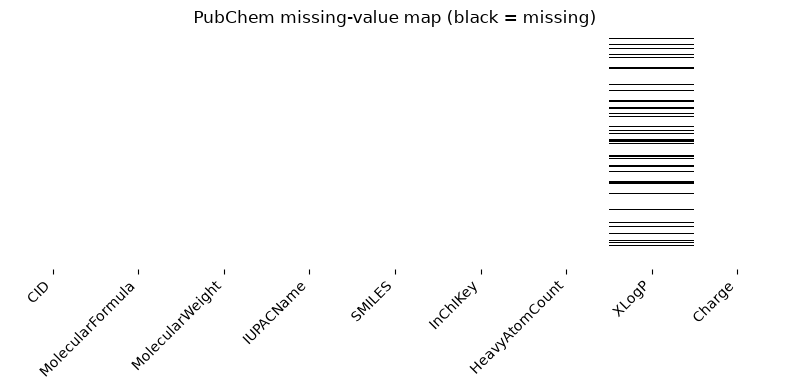

,CID,MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge
21,5282412,C43H47N2NaO6S2,775.00,"sodium 4-[(2Z)-2-[(2E,4E,6E)-7-[1,1-dimethyl-3...",CC1(C(=[N+](C2=C1C3=CC=CC=C3C=C2)CCCCS(=O)(=O)...,MOFVSTNWEDAEEK-UHFFFAOYSA-M,54,NaN,0
38,11079,C14H15ClN2,246.73,"2-(naphthalen-1-ylmethyl)-4,5-dihydro-1H-imida...",C1CN=C(N1)CC2=CC=CC3=CC=CC=C32.Cl,DJDFFEBSKJCGHC-UHFFFAOYSA-N,17,NaN,0
39,62882,C16H22ClNO2,295.80,1-naphthalen-1-yloxy-3-(propan-2-ylamino)propa...,CC(C)NCC(COC1=CC=CC2=CC=CC=C21)O.Cl,ZMRUPTIKESYGQW-UHFFFAOYSA-N,20,NaN,0
50,5281033,C34H30N2O6S,594.70,4-[(3-carboxy-2-hydroxynaphthalen-1-yl)methyl]...,CN1CCCN=C1/C=C/C2=CC=CS2.C1=CC=C2C(=C1)C=C(C(=...,AQXXZDYPVDOQEE-MXDQRGINSA-N,43,NaN,0
68,60834,C18H20ClNOS,333.90,(3S)-N-methyl-3-naphthalen-1-yloxy-3-thiophen-...,CNCC[C@@H](C1=CC=CS1)OC2=CC=CC3=CC=CC=C32.Cl,BFFSMCNJSOPUAY-LMOVPXPDSA-N,22,NaN,0
69,23681059,C14H13NaO3,252.24,sodium (2S)-2-(6-methoxynaphthalen-2-yl)propan...,C[C@@H](C1=CC2=C(C=C1)C=C(C=C2)OC)C(=O)[O-].[Na+],CDBRNDSHEYLDJV-FVGYRXGTSA-M,18,NaN,0
76,312915,C26H35NO7,473.60,2-(diethylamino)ethyl 2-(naphthalen-1-ylmethyl...,CCN(CC)CCOC(=O)C(CC1CCCO1)CC2=CC=CC3=CC=CC=C32...,SSAJNPNVUYMUCI-UHFFFAOYSA-N,34,NaN,0
104,156418,C22H23ClF3N,393.90,N-[(1R)-1-naphthalen-1-ylethyl]-3-[3-(trifluor...,C[C@H](C1=CC=CC2=CC=CC=C21)NCCCC3=CC(=CC=C3)C(...,QANQWUQOEJZMLL-PKLMIRHRSA-N,27,NaN,0
106,23667630,C21H21N2NaO5S,436.50,"sodium (2S,5R,6R)-6-[(2-ethoxynaphthalene-1-ca...",CCOC1=C(C2=CC=CC=C2C=C1)C(=O)N[C@H]3[C@@H]4N(C...,AYAPZOUDXCDGIF-FRFVDRIFSA-M,30,NaN,0
109,8514,C51H34N6Na6O23S6,1429.20,hexasodium;8-[[4-methyl-3-[[3-[[3-[[2-methyl-5...,CC1=C(C=C(C=C1)C(=O)NC2=C3C(=CC(=CC3=C(C=C2)S(...,VAPNKLKDKUDFHK-UHFFFAOYSA-H,92,NaN,0


In [10]:
# Visual inspection: a missingness heatmap gives a one-shot overview of where values are
# missing across the whole PubChem dataframe (similar to missingno's matrix plot). Each
# row is a compound and each column a variable; missing cells show as black bands. XLogP
# is the one column with visible gaps.
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_pubchem.isna(), cbar=False, cmap="Greys", yticklabels=False, ax=ax)
ax.set_title("PubChem missing-value map (black = missing)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# A closer look at the specific rows where XLogP is missing:
df_pubchem[df_pubchem["XLogP"].isna()].head(10)

In [7]:
# Programmatic inspection: count the missing values per column, then report the exact
# count and percentage for XLogP.
print("Missing values per column:")
print(df_pubchem.isna().sum())

n_missing = df_pubchem["XLogP"].isna().sum()
print(
    f"\nXLogP missing: {n_missing} of {len(df_pubchem)} "
    f"({df_pubchem['XLogP'].isna().mean() * 100:.1f}%)"
)

Missing values per column:
CID                  0
MolecularFormula     0
MolecularWeight      0
IUPACName            1
SMILES               0
InChIKey             0
HeavyAtomCount       0
XLogP               93
Charge               0
dtype: int64

XLogP missing: 93 of 700 (13.3%)


Issue and justification: The PubChem `XLogP` column is **incomplete** — 93 of the 700 compounds (~13%) have no value (`NaN`). XLogP is a *computed* octanol–water partition coefficient that PubChem does not report for every compound, so the gaps arise at the source. This is a **completeness** data-quality problem (one of the data-quality pillars).

*Justification of methods:* the **visual** check filters the dataframe to the rows where `XLogP` is missing, making the empty/`NaN` cells directly visible; the **programmatic** check uses `isna().sum()` to count missing values per column and reports the exact count and percentage for `XLogP`, objectively confirming the scale of the gap.

### Quality Issue 2: The two datasets write the molecular formula in different formats (consistency)

To combine the datasets later, we need a shared column whose values match on both sides — the natural choice is the **molecular formula** (e.g. `C10H8`). The problem: the two sources format that formula differently. PubChem always writes the plain, neutral formula (`C10H8`), while PAHdb bakes the molecule's electric charge into the text — a `+` for a positive ion, `-` for a negative ion, and `+2`/`+3` for doubly/triply charged ones (e.g. `C10H8+`, `C9H7+2`, `C10H8-`). So the same molecule reads as `C10H8` in one table and `C10H8+` in the other, and a direct match would silently drop all the charged molecules.

In [11]:
# Visual inspection: put the two formula columns side by side so the format difference
# is obvious. PAHdb bakes the charge into the formula text (trailing +, -, +2, +3),
# while PubChem's MolecularFormula is always the neutral form. Show two example
# molecules from each PAHdb charge state.
pahdb_examples = df_pahdb.groupby("charge").head(2).sort_values("charge")
print("PAHdb - the charge is written into the 'formula' text (see the +/- suffixes):")
display(pahdb_examples[["uid", "formula", "charge"]])

print("\nPubChem - 'MolecularFormula' is always neutral (no +/- suffix):")
display(df_pubchem[["CID", "MolecularFormula", "Charge"]].head(6))

PAHdb - the charge is written into the 'formula' text (see the +/- suffixes):


,uid,formula,charge
15,382,C10H8-,-1
16,384,C10H9-,-1
0,430,C6H6O,0
1,428,C6H6O,0
2,431,C6H6O+,1
3,429,C6H6O+,1
13,4415,C9H7+2,2
14,4416,C9H8+2,2
5154,194,C47H17+3,3
5339,103,C48H20+3,3



PubChem - 'MolecularFormula' is always neutral (no +/- suffix):


,CID,MolecularFormula,Charge
0,931,C10H8,0
1,6129,C12H11NO2,0
2,2336,C20H12,0
3,3503,C30H30O8,0
4,8418,C14H10,0
5,8663,C10H8O,0


In [12]:
# Programmatic inspection: quantify the problem.
# 1) How many PAHdb formulas carry a +/- charge symbol (so they can never match
#    PubChem's neutral formula as-is)?
charged_mask = df_pahdb["formula"].str.contains(r"[+-]", regex=True)
print(f"PAHdb formulas containing a +/- charge symbol: "
      f"{charged_mask.sum()} of {len(df_pahdb)}")

# 2) Compare matches against PubChem's formulas BEFORE vs AFTER removing the charge.
pubchem_formulas = set(df_pubchem["MolecularFormula"])

# Raw match: PAHdb's formula text exactly as-is.
raw_match = df_pahdb["formula"].isin(pubchem_formulas).sum()

# Neutralised match: strip a trailing +, -, +2, +3, etc. before comparing.
neutral_formula = df_pahdb["formula"].str.replace(r"[+-]\d*$", "", regex=True)
neutral_match = neutral_formula.isin(pubchem_formulas).sum()

print(f"PAHdb rows matching a PubChem formula - raw text:        {raw_match}")
print(f"PAHdb rows matching a PubChem formula - after stripping: {neutral_match}")
print(f"Extra molecules recovered by fixing the format: {neutral_match - raw_match}")

PAHdb formulas containing a +/- charge symbol: 6270 of 10749
PAHdb rows matching a PubChem formula - raw text:        110
PAHdb rows matching a PubChem formula - after stripping: 271
Extra molecules recovered by fixing the format: 161


Issue and justification: The molecular formula is stored **inconsistently** across the two datasets. PubChem always uses the neutral formula (e.g. `C10H8`), but PAHdb writes the charge into the same field (`C10H8+`, `C9H7+2`, `C10H8-`). Because these are just text, the same molecule does not match across the tables, so a straight join would throw away every charged molecule — which are exactly the "ionized aromatics" our research question needs. This is a **consistency** data-quality problem (one of the data-quality pillars). PAHdb already records the charge in its own `charge` column, so the `+`/`-` in the formula is redundant and can safely be removed during cleaning, leaving a neutral formula that matches PubChem.

*Justification of methods:* the **visual** check places the two formula columns side by side (two examples per charge state) so the differing formats are immediately apparent; the **programmatic** check counts how many PAHdb formulas contain a charge symbol and shows how many more molecules match PubChem once the charge is stripped, objectively confirming the size of the problem.

### Tidiness Issue 1: A single molecule's data is split across two tables

Tidy data expects all the facts about one observation to live together. Here the observational unit is **a molecule**, but its information is spread across the two datasets: PubChem holds the molecule's **structure** (weight, carbon/heavy-atom count, name) with no spectrum, while PAHdb holds the molecule's **infrared spectrum** and charge with none of PubChem's structural properties. Our research question needs *molecular size* and *number of emission lines* on the same row, so neither table is sufficient on its own — the two must be merged into one table.

In [13]:
# Visual inspection: look at the head of each table. The facts about a single molecule
# are split across the two - PubChem holds the structure, PAHdb holds the spectrum.
print("PubChem table - structural properties, but NO spectrum:")
display(df_pubchem.head(3))

print("\nPAHdb table - the spectrum (frequencies/intensities) and charge, but NO structural properties:")
display(df_pahdb.head(3))

PubChem table - structural properties, but NO spectrum:


,CID,MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,XLogP,Charge
0,931,C10H8,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,3.3,0
1,6129,C12H11NO2,201.22,naphthalen-1-yl N-methylcarbamate,CNC(=O)OC1=CC=CC2=CC=CC=C21,CVXBEEMKQHEXEN-UHFFFAOYSA-N,15,2.4,0
2,2336,C20H12,252.30,benzo[a]pyrene,C1=CC=C2C3=C4C(=CC2=C1)C=CC5=C4C(=CC=C5)C=C3,FMMWHPNWAFZXNH-UHFFFAOYSA-N,20,6.0,0



PAHdb table - the spectrum (frequencies/intensities) and charge, but NO structural properties:


,uid,formula,charge,weight,symmetry,method,frequencies,intensities
0,430,C6H6O,0,94.04186000,1-A',RB3LYP,68.22150000;266.11240000;438.55110000;445.6087...,6.57630000;0.00280000;0.00300000;8.90640000;11...
1,428,C6H6O,0,94.04186000,1-A',RB3LYP,228.83890000;351.24410000;398.38840000;413.898...,0.63210000;123.24690000;9.97170000;0.16920000;...
2,431,C6H6O+,1,94.04186000,2-A,UB3LYP,112.16990000;245.00450000;400.63220000;423.474...,7.54030000;4.52050000;2.94200000;15.97010000;2...


In [14]:
# Programmatic inspection: the two tables describe the same observational unit (a
# molecule) but hold different variables, so neither table alone has everything the
# research question needs.
print("PubChem columns:", list(df_pubchem.columns))
print("PAHdb columns:  ", list(df_pahdb.columns))

need_size = "MolecularWeight"   # a molecular-size variable (expected in PubChem)
need_lines = "frequencies"      # the emission lines (expected in PAHdb)
print(f"\n'{need_size}'  in PubChem? {need_size in df_pubchem.columns};  in PAHdb? {need_size in df_pahdb.columns}")
print(f"'{need_lines}'    in PubChem? {need_lines in df_pubchem.columns};  in PAHdb? {need_lines in df_pahdb.columns}")
print("\n=> No single table holds both molecular size and emission lines: "
      "the molecule's data is split across two tables and must be merged.")

PubChem columns: ['CID', 'MolecularFormula', 'MolecularWeight', 'IUPACName', 'SMILES', 'InChIKey', 'HeavyAtomCount', 'XLogP', 'Charge']
PAHdb columns:   ['uid', 'formula', 'charge', 'weight', 'symmetry', 'method', 'frequencies', 'intensities']

'MolecularWeight'  in PubChem? True;  in PAHdb? False
'frequencies'    in PubChem? False;  in PAHdb? True

=> No single table holds both molecular size and emission lines: the molecule's data is split across two tables and must be merged.


Issue and justification: The data for a single observational unit — one molecule — is **split across two tables**. PubChem provides the structural variables (molecular weight, heavy-atom count, name) and PAHdb provides the spectral variables (emission-line frequencies/intensities) and charge, but neither table contains both. This violates the tidiness rule that all variables describing one observation should sit together in a single table. The fix during cleaning is to **merge** the two tables on the shared (cleaned) molecular-formula key, producing one row per molecule with both its structure and its spectrum.

*Justification of methods:* the **visual** check shows the head of each table so it is plain that structure lives in one and spectra in the other; the **programmatic** check lists each table's columns and confirms that the two variables the research question needs (`MolecularWeight` and `frequencies`) never appear together in one table.

### Tidiness Issue 2: Many values packed into a single cell (frequencies / intensities)

Each molecule in PAHdb has many vibrational modes — the individual infrared emission lines. In the parsed table these are stored as long `;`-separated strings inside a single `frequencies` cell (and a matching `intensities` cell). That breaks the tidy-data rule that each cell should hold exactly **one** value. In effect the emission line is a second observational unit that has been crammed into the molecule's row. The fix during cleaning is to split these out with `explode()` into a separate **transitions** table (one row per emission line, keyed by `uid`), and to keep a derived per-molecule count (`n_lines`) on the molecule table for the research question.

In [16]:
# Visual inspection: look at a single molecule's frequencies/intensities cells. Each
# holds many values (one per vibrational mode) joined by ';' - not one value per cell.
example = df_pahdb.iloc[0]
print(f"Molecule: uid={example['uid']}, formula={example['formula']}")
print("\n'frequencies' cell (first 200 chars):")
print(example["frequencies"][:200], "...")
print("\n'intensities' cell (first 200 chars):")
print(example["intensities"][:200], "...")
print(f"\nNumber of values packed into this one 'frequencies' cell: "
      f"{len(example['frequencies'].split(';'))}")

Molecule: uid=430, formula=C6H6O

'frequencies' cell (first 200 chars):
68.22150000;266.11240000;438.55110000;445.60870000;483.74480000;531.95550000;567.77560000;710.60870000;735.46260000;803.94580000;930.06950000;934.18290000;941.05040000;971.88210000;985.95210000;1002.5 ...

'intensities' cell (first 200 chars):
6.57630000;0.00280000;0.00300000;8.90640000;11.23810000;5.61940000;0.70340000;51.65170000;7.54570000;2.87390000;2.52760000;2.97400000;3.28530000;0.92520000;10.86180000;0.28580000;16.20690000;4.4686000 ...

Number of values packed into this one 'frequencies' cell: 33


In [15]:
# Programmatic inspection: count how many values are packed into each 'frequencies'
# cell (i.e. how many emission lines each molecule has).
n_values = df_pahdb["frequencies"].str.split(";").str.len()
print("Values per 'frequencies' cell (emission lines per molecule):")
print(n_values.describe())

print(f"\nRows with more than one value in the cell: "
      f"{(n_values > 1).sum()} of {len(df_pahdb)}")
print(f"Total emission lines packed across all molecules: {n_values.sum():,}")

Values per 'frequencies' cell (emission lines per molecule):
count    10749.000000
mean       234.198437
std        120.850949
min         33.000000
25%        144.000000
50%        204.000000
75%        351.000000
max       1290.000000
Name: frequencies, dtype: float64

Rows with more than one value in the cell: 10749 of 10749
Total emission lines packed across all molecules: 2,517,399


Issue and justification: The `frequencies` and `intensities` columns each hold **many values in a single cell** (hundreds of `;`-separated numbers per molecule — one per vibrational mode). This violates the tidiness rule that each cell should contain a single value; really, the emission line is a separate observational unit that has been packed into the molecule's row. During cleaning we will treat the emission lines as their own observational unit: `explode()` splits the packed cells into a separate **transitions** table (one row per emission line, keyed by `uid`), avoiding the heavy duplication that a single denormalised table would create, and we keep a derived `n_lines` count on the molecule table for the research question.

*Justification of methods:* the **visual** check prints one molecule's `frequencies`/`intensities` cells so the packed, multi-value strings are directly visible; the **programmatic** check counts the values per cell across all rows (`str.split(';').str.len()`) and summarises them, objectively showing that essentially every cell holds many values.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [20]:
# Work on copies so the raw dataframes (df_pahdb, df_pubchem) stay untouched.
df_pahdb_clean = df_pahdb.copy()
df_pubchem_clean = df_pubchem.copy()

print("df_pahdb_clean:  ", df_pahdb_clean.shape)
print("df_pubchem_clean:", df_pubchem_clean.shape)

df_pahdb_clean:   (10749, 8)
df_pubchem_clean: (700, 9)


### **Quality Issue 1: Missing values in the PubChem `XLogP` column (completeness)**

In [21]:
# Cleaning strategy: XLogP (a computed hydrophobicity value) is missing for ~13% of the
# compounds and is NOT needed for the research question, which uses molecular size and
# the emission-line count. Imputing a physicochemical property would fabricate data, and
# dropping the 93 rows would needlessly discard molecules, so we drop the XLogP COLUMN.
df_pubchem_clean = df_pubchem_clean.drop(columns=["XLogP"])

In [22]:
# Validate: XLogP is gone, and no missing values remain in the columns we keep
# (aside from a single missing IUPACName - a text label we do not use for the analysis).
print("XLogP still a column?", "XLogP" in df_pubchem_clean.columns)
print("\nMissing values per remaining PubChem column:")
print(df_pubchem_clean.isna().sum())

XLogP still a column? False

Missing values per remaining PubChem column:
CID                 0
MolecularFormula    0
MolecularWeight     0
IUPACName           1
SMILES              0
InChIKey            0
HeavyAtomCount      0
Charge              0
dtype: int64


Justification: `XLogP` is a computed octanol–water partition coefficient (a hydrophobicity measure) that PubChem does not report for every compound, so ~13% of values are missing at the source. It plays **no role** in the research question, which relates molecular *size* to the *number of emission lines*. Two common completeness fixes are both worse here: **imputing** would invent chemical values that were never measured, and **dropping the 93 rows** would throw away otherwise-usable molecules. Removing the single incomplete **column** eliminates the completeness problem while keeping every molecule and every variable we actually need. (One `IUPACName` is also missing, but that is only a human-readable label and is not used in the analysis, so it is left as-is.)

*Validation:* the check confirms `XLogP` is no longer a column and lists the remaining missing-value counts, showing the dataset is now complete for the variables we will use.

### **Quality Issue 2: Inconsistent molecular-formula format (charge baked into the PAHdb formula)**

In [23]:
# Cleaning strategy: create a neutral 'formula_clean' by stripping the trailing charge
# symbol (+, -, +2, +3) from the PAHdb formula, so it can be matched to PubChem's neutral
# MolecularFormula. The original 'charge' column is left untouched, so the neutral-vs-ion
# information is fully preserved. We also add a readable 'charge_state' label (derived
# from 'charge') to make the neutral/cation/anion grouping easy in the analysis.
df_pahdb_clean["formula_clean"] = df_pahdb_clean["formula"].str.replace(
    r"[+-]\d*$", "", regex=True
)

# Human-readable ionization label: 0 -> neutral, -1 -> anion, 1/2/3 -> cation.
charge_to_state = {"0": "neutral", "-1": "anion"}
df_pahdb_clean["charge_state"] = (
    df_pahdb_clean["charge"].map(charge_to_state).fillna("cation")
)

df_pahdb_clean[["uid", "formula", "charge", "formula_clean", "charge_state"]].head()

,uid,formula,charge,formula_clean,charge_state
0,430,C6H6O,0,C6H6O,neutral
1,428,C6H6O,0,C6H6O,neutral
2,431,C6H6O+,1,C6H6O,cation
3,429,C6H6O+,1,C6H6O,cation
4,432,C6H7O+,1,C6H7O,cation


In [24]:
# Validate: no 'formula_clean' value still contains a charge symbol, and the neutral vs
# ion information is preserved via 'charge_state'.
still_charged = df_pahdb_clean["formula_clean"].str.contains(r"[+-]").sum()
print("formula_clean values still containing +/-:", still_charged)

print("\ncharge_state counts (neutral vs ions preserved):")
print(df_pahdb_clean["charge_state"].value_counts())

# A molecule's neutral form and its ions now share the same formula_clean:
print("\nExample - naphthalene neutral and its ions all share formula_clean 'C10H8':")
display(
    df_pahdb_clean[df_pahdb_clean["formula_clean"] == "C10H8"]
    [["uid", "formula", "charge", "charge_state", "formula_clean"]].head()
)

formula_clean values still containing +/-: 0

charge_state counts (neutral vs ions preserved):
charge_state
cation     5039
neutral    4479
anion      1231
Name: count, dtype: int64

Example - naphthalene neutral and its ions all share formula_clean 'C10H8':


,uid,formula,charge,charge_state,formula_clean
15,382,C10H8-,-1,anion,C10H8
22,330,C10H8,0,neutral,C10H8
55,359,C10H8+,1,cation,C10H8
80,4374,C10H8+2,2,cation,C10H8


Justification: The molecular formula was stored inconsistently — PubChem uses the neutral formula (`C10H8`) while PAHdb writes the charge into the formula text (`C10H8+`, `C9H7+2`, `C10H8-`). We create a new `formula_clean` column that removes the trailing charge symbol with a regular expression (`[+-]\d*$`), producing a neutral formula that matches PubChem's format and can serve as the join key. Crucially, we do **not** touch the original `charge` column, so no information is lost: neutrals and ions remain fully distinguishable. To make that distinction easy to use later, we also derive a readable `charge_state` label (`neutral` / `cation` / `anion`) from `charge`. Keeping the original `formula` alongside `formula_clean` preserves an audit trail of the change.

*Validation:* the check confirms that no `formula_clean` value still contains a `+`/`-`, shows the `charge_state` counts (neutrals and ions both retained), and demonstrates that a molecule's neutral and ionised forms now share the same `formula_clean` (e.g. all forms of `C10H8`), which is exactly what makes the later merge — and the neutral-vs-ion comparison — work.

### **Tidiness Issue 1: A single molecule's data is split across two tables (merge)**

In [25]:
# Cleaning strategy: bring the two tables together so each molecule's structure (PubChem)
# and its spectral summary (PAHdb) sit on one row. First derive n_lines - the number of
# emission lines per molecule, which is the spectral variable the research question needs.
# (The packed frequency/intensity strings themselves are tidied in Tidiness Issue 2.)
df_pahdb_clean["n_lines"] = df_pahdb_clean["frequencies"].str.split(";").str.len()

# Molecule-level view of PAHdb: the join key, the ionization info, and the line count.
pahdb_molecules = df_pahdb_clean[
    ["uid", "formula_clean", "charge", "charge_state", "n_lines"]
]

# Merge on the cleaned formula. An inner join keeps only molecules present in BOTH sources.
# The join is one-to-many: one PubChem structure links to the molecule's neutral and
# ionised PAHdb forms, each keeping its own charge_state and n_lines.
df_merged = pahdb_molecules.merge(
    df_pubchem_clean,
    left_on="formula_clean",
    right_on="MolecularFormula",
    how="inner",
)
print("Merged shape:", df_merged.shape)
df_merged.head()

Merged shape: (1136, 13)


,uid,formula_clean,charge,charge_state,n_lines,CID,MolecularFormula,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,Charge
0,382,C10H8,-1,anion,48,931,C10H8,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
1,330,C10H8,0,neutral,48,931,C10H8,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
2,499,C10H8O,0,neutral,51,8663,C10H8O,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0
3,499,C10H8O,0,neutral,51,7005,C10H8O,144.17,naphthalen-1-ol,C1=CC=C2C(=C1)C=CC=C2O,KJCVRFUGPWSIIH-UHFFFAOYSA-N,11,0
4,497,C10H8O,0,neutral,51,8663,C10H8O,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0


In [26]:
# Validate: the merged table now holds BOTH structural (PubChem) and spectral (PAHdb)
# variables in one row, so the data is no longer split across two tables.
print("Merged columns:", list(df_merged.columns))
print(f"\nHas molecular size (MolecularWeight)? {'MolecularWeight' in df_merged.columns}")
print(f"Has emission-line count (n_lines)?    {'n_lines' in df_merged.columns}")

print(f"\nMolecules (rows) in merged dataset: {len(df_merged)}")
print("\ncharge_state breakdown in merged data (neutrals and ions both present):")
print(df_merged["charge_state"].value_counts())

Merged columns: ['uid', 'formula_clean', 'charge', 'charge_state', 'n_lines', 'CID', 'MolecularFormula', 'MolecularWeight', 'IUPACName', 'SMILES', 'InChIKey', 'HeavyAtomCount', 'Charge']

Has molecular size (MolecularWeight)? True
Has emission-line count (n_lines)?    True

Molecules (rows) in merged dataset: 1136

charge_state breakdown in merged data (neutrals and ions both present):
charge_state
cation     630
neutral    450
anion       56
Name: count, dtype: int64


Justification: The molecule's information was split across two tables — structure in PubChem, spectrum in PAHdb. We resolve this by **merging** the two on the cleaned formula key (`formula_clean` ↔ `MolecularFormula`), producing one row per molecule *per charge state* that carries both the structural variables and the derived emission-line count (`n_lines`). An **inner** join is used deliberately: it keeps only molecules that exist in *both* sources, which is exactly the set the research question can actually be answered for. The join is intentionally one-to-many — a single PubChem structure links to the molecule's neutral and ionised PAHdb forms — so the neutral-vs-ion comparison is retained via `charge_state`. Note that molecular formula is not a perfect key (structural isomers share a formula), which is a known limitation we record for the reflection.

*Validation:* the check lists the merged columns and confirms that both a size variable (`MolecularWeight`) and the spectral count (`n_lines`) are now present in a single table, and shows that neutrals and ions are both represented — demonstrating the data is no longer split across tables.

### **Tidiness Issue 2: Many values per cell → a separate transitions table (explode)**

In [27]:
# Cleaning strategy: the emission lines are a second observational unit, so we split the
# packed 'frequencies'/'intensities' cells into a SEPARATE tidy transitions table - one
# row per emission line, keyed by uid - using explode(). Keeping this as its own table
# (rather than exploding into the molecule table) avoids duplicating molecule attributes
# across millions of rows. We build it for the molecules kept in the merged dataset.
merged_uids = df_merged["uid"].unique()
transitions_src = df_pahdb_clean[df_pahdb_clean["uid"].isin(merged_uids)][
    ["uid", "frequencies", "intensities"]
].copy()

# Split the ';'-joined strings into lists, then explode the paired columns together so
# each emission line becomes its own row with a single frequency and intensity value.
transitions_src["frequency"] = transitions_src["frequencies"].str.split(";")
transitions_src["intensity"] = transitions_src["intensities"].str.split(";")
df_transitions = (
    transitions_src.explode(["frequency", "intensity"])[["uid", "frequency", "intensity"]]
    .reset_index(drop=True)
)

# Convert the split values from text to numbers.
df_transitions["frequency"] = df_transitions["frequency"].astype(float)
df_transitions["intensity"] = df_transitions["intensity"].astype(float)

print("Transitions table shape:", df_transitions.shape)
df_transitions.head()

Transitions table shape: (22710, 3)


,uid,frequency,intensity
0,382,165.5162,0.0000
1,382,177.6307,2.1953
2,382,298.9093,0.0000
3,382,357.4740,4.2497
4,382,467.0456,2.5744


In [28]:
# Validate: every cell now holds a single numeric value, and the number of lines per
# molecule in the transitions table matches the n_lines we derived from the packed cells.
print("Column dtypes (one numeric value per cell):")
print(df_transitions.dtypes)

# Cross-check line counts: transitions grouped by uid vs the n_lines summary.
lines_per_uid = df_transitions.groupby("uid").size()
n_lines_by_uid = df_merged.drop_duplicates("uid").set_index("uid")["n_lines"]
matches = (lines_per_uid == n_lines_by_uid.reindex(lines_per_uid.index)).all()
print(f"\nPer-molecule line counts match n_lines? {matches}")
print(f"Molecules represented: {df_transitions['uid'].nunique()}")
print(f"Total emission lines in transitions table: {len(df_transitions):,}")

Column dtypes (one numeric value per cell):
uid              str
frequency    float64
intensity    float64
dtype: object

Per-molecule line counts match n_lines? True
Molecules represented: 271
Total emission lines in transitions table: 22,710


Justification: The `frequencies` and `intensities` columns packed many values into one cell. Because an emission line is really its own observational unit, the tidy fix is to give it its **own table**: we use `explode()` to split the paired lists into a `df_transitions` table with one row per emission line (`uid`, `frequency`, `intensity`), and convert the values from text to numbers. Keeping the lines in a separate table (rather than exploding them into the molecule table) follows the tidy rule "each type of observational unit forms a table" and avoids duplicating every molecule-level attribute across the ~2.5 million lines. The molecule-level summary the research question needs — `n_lines` — already lives on the merged table, so the molecule table stays one row per molecule while the full line-level detail is preserved separately. We scope the transitions table to the molecules kept in the merged dataset, since those are the ones the analysis uses.

*Validation:* the check confirms each column now holds a single numeric value (via `dtypes`) and that the per-molecule line counts in the transitions table exactly match the `n_lines` derived earlier, proving no lines were lost or duplicated.

### **Remove unnecessary variables and combine datasets**

The datasets were already **combined** in Tidiness Issue 1 (the merge into `df_merged`). Here we remove only one variable that carries no new information: `MolecularFormula`, which after the merge is an exact duplicate of the `formula_clean` join key. We deliberately **keep** columns such as `SMILES`, `InChIKey`, `HeavyAtomCount` and PubChem's `Charge` — even though the current research question does not use them — so the dataset stays useful for a future extension of the analysis.

In [29]:
# Remove only variables that carry no new information. Here that is 'MolecularFormula':
# after the inner merge it is an exact duplicate of 'formula_clean' (the join key).
# Everything else is kept - including SMILES, InChIKey, HeavyAtomCount and PubChem's
# 'Charge' - for possible future analysis beyond this project's research question.
# (PubChem 'Charge' is mostly 0 but not constant - two compounds are +1 - so it is kept.)
print("MolecularFormula equals formula_clean for every row?",
      (df_merged["MolecularFormula"] == df_merged["formula_clean"]).all())

df_final = df_merged.drop(columns=["MolecularFormula"])

print("\nFinal combined dataset shape:", df_final.shape)
print("Final columns:", list(df_final.columns))
df_final.head()

MolecularFormula equals formula_clean for every row? True

Final combined dataset shape: (1136, 12)
Final columns: ['uid', 'formula_clean', 'charge', 'charge_state', 'n_lines', 'CID', 'MolecularWeight', 'IUPACName', 'SMILES', 'InChIKey', 'HeavyAtomCount', 'Charge']


,uid,formula_clean,charge,charge_state,n_lines,CID,MolecularWeight,IUPACName,SMILES,InChIKey,HeavyAtomCount,Charge
0,382,C10H8,-1,anion,48,931,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
1,330,C10H8,0,neutral,48,931,128.17,naphthalene,C1=CC=C2C=CC=CC2=C1,UFWIBTONFRDIAS-UHFFFAOYSA-N,10,0
2,499,C10H8O,0,neutral,51,8663,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0
3,499,C10H8O,0,neutral,51,7005,144.17,naphthalen-1-ol,C1=CC=C2C(=C1)C=CC=C2O,KJCVRFUGPWSIIH-UHFFFAOYSA-N,11,0
4,497,C10H8O,0,neutral,51,8663,144.17,naphthalen-2-ol,C1=CC=C2C=C(C=CC2=C1)O,JWAZRIHNYRIHIV-UHFFFAOYSA-N,11,0


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [30]:
# Save the CLEANED datasets to the local data store (data/cleaned/), kept separate from
# the raw files in data/raw/ so both versions are preserved. Files are named informatively.
CLEANED_DIR = os.path.join("data", "cleaned")
os.makedirs(CLEANED_DIR, exist_ok=True)

molecules_path = os.path.join(CLEANED_DIR, "pah_molecules_clean.csv")   # final combined table
transitions_path = os.path.join(CLEANED_DIR, "pah_transitions_clean.csv")  # tidy emission lines
df_final.to_csv(molecules_path, index=False)
df_transitions.to_csv(transitions_path, index=False)

# Confirm both raw and cleaned versions are present in the data store.
print("Raw data (data/raw/):")
for name in [
    "pahdb-complete-theoretical-v4.00.xml",  # manually downloaded PAHdb XML
    "pahdb_theoretical_extracted.csv",        # parsed PAHdb extract
    "pubchem_pah_raw.csv",                     # PubChem API response
]:
    p = os.path.join(RAW_DIR, name)
    status = f"{os.path.getsize(p) / 1_000_000:.2f} MB" if os.path.exists(p) else "MISSING"
    print(f"  {p}  ({status})")

print("\nCleaned data (data/cleaned/):")
for p in [molecules_path, transitions_path]:
    print(f"  {p}  ({os.path.getsize(p) / 1_000_000:.2f} MB)")

Raw data (data/raw/):
  data\raw\pahdb-complete-theoretical-v4.00.xml  (503.34 MB)
  data\raw\pahdb_theoretical_extracted.csv  (62.79 MB)
  data\raw\pubchem_pah_raw.csv  (0.13 MB)

Cleaned data (data/cleaned/):
  data\cleaned\pah_molecules_clean.csv  (0.18 MB)
  data\cleaned\pah_transitions_clean.csv  (0.49 MB)


## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

*Research question:* How does the number of distinct infrared emission lines vary with an aromatic molecule's size (molecular weight or carbon count), and do neutral and ionized aromatics differ in this respect?

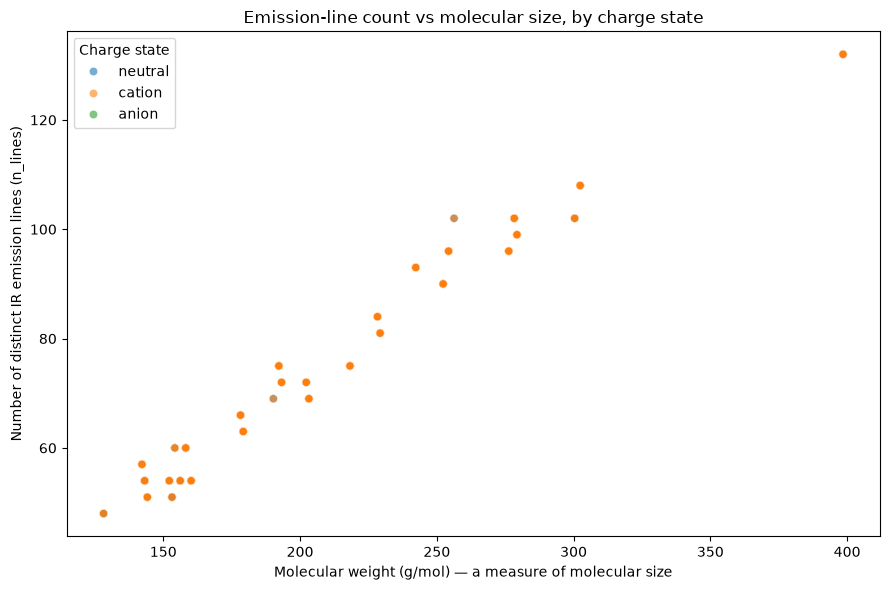

In [31]:
# Visual 1: relate the number of emission lines to molecular size, coloured by charge
# state. Each point is one molecule (in a given charge state) from the cleaned dataset.
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df_final,
    x="MolecularWeight",
    y="n_lines",
    hue="charge_state",
    hue_order=["neutral", "cation", "anion"],
    alpha=0.6,
    ax=ax,
)
ax.set_xlabel("Molecular weight (g/mol) — a measure of molecular size")
ax.set_ylabel("Number of distinct IR emission lines (n_lines)")
ax.set_title("Emission-line count vs molecular size, by charge state")
ax.legend(title="Charge state")
plt.tight_layout()
plt.show()

*Answer to research question:* The scatter plot shows a clear, roughly **linear increase** in the number of distinct IR emission lines as molecular weight (size) grows — larger aromatic molecules have more emission lines. This is expected: the number of vibrational modes of a molecule is fixed by its atom count (`3N − 6`), so more atoms means more lines. The neutral, cation and anion points **overlap almost exactly** at each molecular weight — but this is true *by construction*, not an empirical surprise: a molecule and its ions have the same atoms, so they always have the same number of lines. In other words, ionization cannot change the *count* of emission lines; it changes only *where* the lines fall and *how strong* they are. The line count therefore answers only the "size" half of the question; to compare neutral versus ionized aromatics we must look at a charge-sensitive property, which Visual 2 does using the total IR intensity.

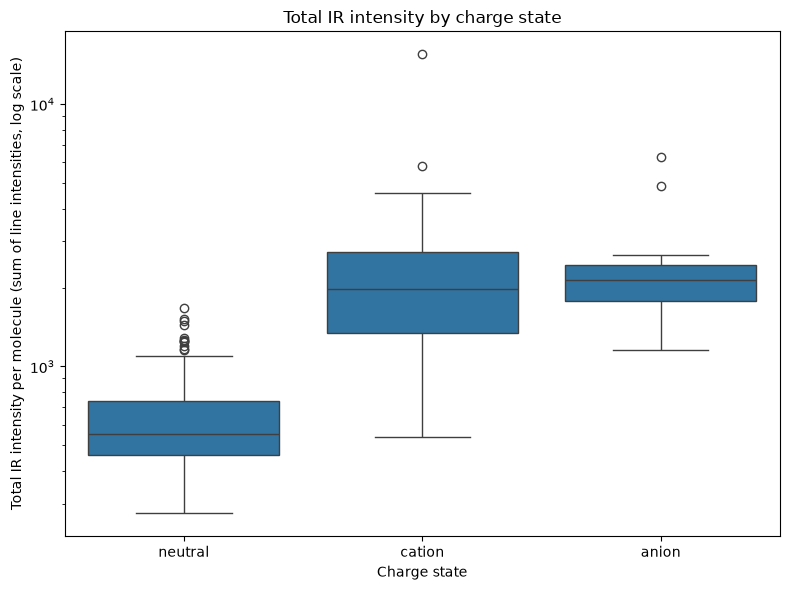

Median total IR intensity per molecule, by charge state:
charge_state
anion      2127.0
cation     1982.3
neutral     554.3
Name: total_intensity, dtype: float64


In [32]:
# Visual 2: compare the charge states on a spectral property that CAN differ between them
# - the total IR intensity per molecule (the sum of all its line intensities). Unlike the
# line count (fixed by atom number), intensity changes with ionization. We use the tidy
# transitions table to sum intensities per molecule, attach the charge_state, and compare.
total_intensity = (
    df_transitions.groupby("uid")["intensity"].sum().rename("total_intensity")
)
mol_intensity = df_final.drop_duplicates("uid").merge(total_intensity, on="uid")

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=mol_intensity,
    x="charge_state",
    y="total_intensity",
    order=["neutral", "cation", "anion"],
    ax=ax,
)
ax.set_yscale("log")  # intensities are strongly right-skewed, so a log scale is clearer
ax.set_xlabel("Charge state")
ax.set_ylabel("Total IR intensity per molecule (sum of line intensities, log scale)")
ax.set_title("Total IR intensity by charge state")
plt.tight_layout()
plt.show()

# Median total intensity per charge state, to support the visual.
print("Median total IR intensity per molecule, by charge state:")
print(mol_intensity.groupby("charge_state")["total_intensity"].median().round(1))

*Answer to research question:* Comparing the charge states on **total IR intensity** (the sum of all line intensities per molecule) reveals the large, real difference that the line count could not. Ionized aromatics are far **brighter** in the infrared than neutrals: the median total intensity is about **554** for neutrals versus roughly **1,980** for cations and **2,130** for anions — a threefold-to-fourfold increase upon ionization. So the charge half of the research question is answered not by *how many* lines a molecule has, but by *how strong* they are: neutral and ionized aromatics differ substantially in overall IR intensity, with ions much stronger (a result consistent with the known astrophysics of PAH emission). The anion group is small here (only 14 molecules), so its estimate is less certain than the cation and neutral ones.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

*Answer:* FILL IN